# Assignment 10: Ising Model for the n-Rook Problem

## 1. Problem Definition

The **n-Rook Problem** asks: place $n$ rooks on an $n \times n$ chessboard such that no two rooks attack each other i.e., no two rooks share the same row or column.

We use an Ising model, where the energy function encodes the constraints and gradient-based updates drive the system toward a valid placement.

### Example: 5-Rook Problem on a 5×5 Board

```
     Col 1   Col 2   Col 3   Col 4   Col 5
   +-------+-------+-------+-------+-------+
R1 |   ♜   |       |       |       |       |
   +-------+-------+-------+-------+-------+
R2 |       |       |   ♜   |       |       |
   +-------+-------+-------+-------+-------+
R3 |       |       |       |       |   ♜   |
   +-------+-------+-------+-------+-------+
R4 |       |   ♜   |       |       |       |
   +-------+-------+-------+-------+-------+
R5 |       |       |       |   ♜   |       |
   +-------+-------+-------+-------+-------+
```

A valid solution is a **permutation matrix** — exactly one 1 per row and one 1 per column.

## 2. Ising Model Energy Function and Binary Variables

### Binary Variables

We define binary variables $x_{i,k} \in \{0, 1\}$ where:
- $i$ = row index ($1, 2, \ldots, n$)
- $k$ = column index ($1, 2, \ldots, n$)
- $x_{i,k} = 1$ means a rook is placed at row $i$, column $k$

For $n = 5$, this gives us $5 \times 5 = 25$ binary variables:

$$\begin{bmatrix} x_{11} & x_{12} & x_{13} & x_{14} & x_{15} \\ x_{21} & x_{22} & x_{23} & x_{24} & x_{25} \\ x_{31} & x_{32} & x_{33} & x_{34} & x_{35} \\ x_{41} & x_{42} & x_{43} & x_{44} & x_{45} \\ x_{51} & x_{52} & x_{53} & x_{54} & x_{55} \end{bmatrix}$$

### Energy Function

The energy function penalizes constraint violations. A valid placement has $E = 0$.

$$E = \frac{\gamma}{2} E_1 + \frac{\gamma}{2} E_2$$

**Column constraint** $E_1$ — each column has exactly one rook:

$$E_1 = \sum_{k=1}^{n} \left(\sum_{i=1}^{n} x_{ik} - 1\right)^2$$

**Row constraint** $E_2$ — each row has exactly one rook:

$$E_2 = \sum_{i=1}^{n} \left(\sum_{k=1}^{n} x_{ik} - 1\right)^2$$

$\gamma > 0$ is a penalty weight.

### Optimization Rule

For each variable $x_{i_0, k_0}$, compute the partial derivative:

$$\frac{\partial E}{\partial x_{i_0 k_0}} = \gamma \left(\sum_{i} x_{i, k_0} - 1\right) + \gamma \left(\sum_{k} x_{i_0, k} - 1\right)$$

Update rule:
- If $\frac{\partial E}{\partial x_{i_0 k_0}} > 0$, set $x_{i_0 k_0} = 0$
- If $\frac{\partial E}{\partial x_{i_0 k_0}} < 0$, set $x_{i_0 k_0} = 1$

Variables are updated sequentially (or in random order) until convergence.

## 3. Implementation: Gradient-Based Ising Model Optimization

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

N = 5       # board size
gamma = 10  # constraint penalty weight


def energy(x, gamma):
    """Compute total energy: E = (gamma/2)*E1 + (gamma/2)*E2"""
    n = x.shape[0]
    # Column constraint: each column sums to 1
    E1 = sum((np.sum(x[:, k]) - 1) ** 2 for k in range(n))
    # Row constraint: each row sums to 1
    E2 = sum((np.sum(x[i, :]) - 1) ** 2 for i in range(n))
    return (gamma / 2) * E1 + (gamma / 2) * E2


def partial_derivative(x, gamma, i0, k0):
    """Compute dE/dx_{i0,k0} analytically.

    dE/dx_{i0,k0} = gamma*(sum_i x_{i,k0} - 1) + gamma*(sum_k x_{i0,k} - 1)
    """
    col_sum = np.sum(x[:, k0])
    row_sum = np.sum(x[i0, :])
    return gamma * (col_sum - 1) + gamma * (row_sum - 1)


def is_valid(x):
    """Check if x is a valid permutation matrix (one rook per row and column)."""
    n = x.shape[0]
    return (all(np.sum(x[:, k]) == 1 for k in range(n)) and
            all(np.sum(x[i, :]) == 1 for i in range(n)))


def ising_optimize(n, gamma, max_iter=100, seed=None):
    """Ising model optimization for the n-Rook problem.

    Update rule: compute dE/dx_{ik} for each variable.
      If dE/dx > 0, set x = 0
      If dE/dx < 0, set x = 1
    Variables updated in random order each iteration.
    """
    rng = np.random.RandomState(seed)
    x = rng.randint(0, 2, size=(n, n))

    energies = [energy(x, gamma)]

    for iteration in range(max_iter):
        indices = list(np.ndindex(n, n))
        rng.shuffle(indices)

        changed = False
        for (i0, k0) in indices:
            dE = partial_derivative(x, gamma, i0, k0)
            old_val = x[i0, k0]
            if dE > 0:
                x[i0, k0] = 0
            elif dE < 0:
                x[i0, k0] = 1
            if x[i0, k0] != old_val:
                changed = True

        e = energy(x, gamma)
        energies.append(e)

        # Early stopping if converged
        if e == 0 and is_valid(x):
            break

    return x, energies


def print_board(x):
    """Print chessboard with rook placements."""
    n = x.shape[0]
    header = "    " + "  ".join(f"C{k+1}" for k in range(n))
    print(header)
    for i in range(n):
        row_str = f"R{i+1}  "
        for k in range(n):
            row_str += " ♜ " if x[i, k] == 1 else " . "
        print(row_str)


print(f"Board size: {N}x{N}")
print(f"Binary variables: {N*N}")
print(f"Penalty weight gamma = {gamma}")

Board size: 5x5
Binary variables: 25
Penalty weight gamma = 10


## 4. Run with Different Random Initializations

In [8]:
num_runs = 10
results = []

for run in range(num_runs):
    x_final, energies = ising_optimize(N, gamma, max_iter=100, seed=run)
    valid = is_valid(x_final)
    results.append((run, x_final.copy(), energies, valid))

    status = "VALID" if valid else "INVALID"
    iters = len(energies) - 1
    print(f"Run {run:2d} | {status} | Converged in {iters:3d} iterations | Final energy: {energies[-1]:.0f}")

# Show board for the first valid result
for run, x_final, energies, valid in results:
    if valid:
        print(f"\nExample valid placement (Run {run}):")
        print_board(x_final)
        print(f"\nSolution matrix:\n{x_final}")
        break

# Summary
valid_count = sum(1 for r in results if r[3])
print(f"\nValid solutions found: {valid_count}/{num_runs}")

Run  0 | VALID | Converged in   2 iterations | Final energy: 0
Run  1 | VALID | Converged in   5 iterations | Final energy: 0
Run  2 | VALID | Converged in   3 iterations | Final energy: 0
Run  3 | VALID | Converged in   7 iterations | Final energy: 0
Run  4 | VALID | Converged in   3 iterations | Final energy: 0
Run  5 | VALID | Converged in   5 iterations | Final energy: 0
Run  6 | VALID | Converged in   3 iterations | Final energy: 0
Run  7 | VALID | Converged in   3 iterations | Final energy: 0
Run  8 | VALID | Converged in   7 iterations | Final energy: 0
Run  9 | VALID | Converged in   2 iterations | Final energy: 0

Example valid placement (Run 0):
    C1  C2  C3  C4  C5
R1   .  .  ♜  .  . 
R2   ♜  .  .  .  . 
R3   .  .  .  ♜  . 
R4   .  .  .  .  ♜ 
R5   .  ♜  .  .  . 

Solution matrix:
[[0 0 1 0 0]
 [1 0 0 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]
 [0 1 0 0 0]]

Valid solutions found: 10/10


## 5. Results Visualization

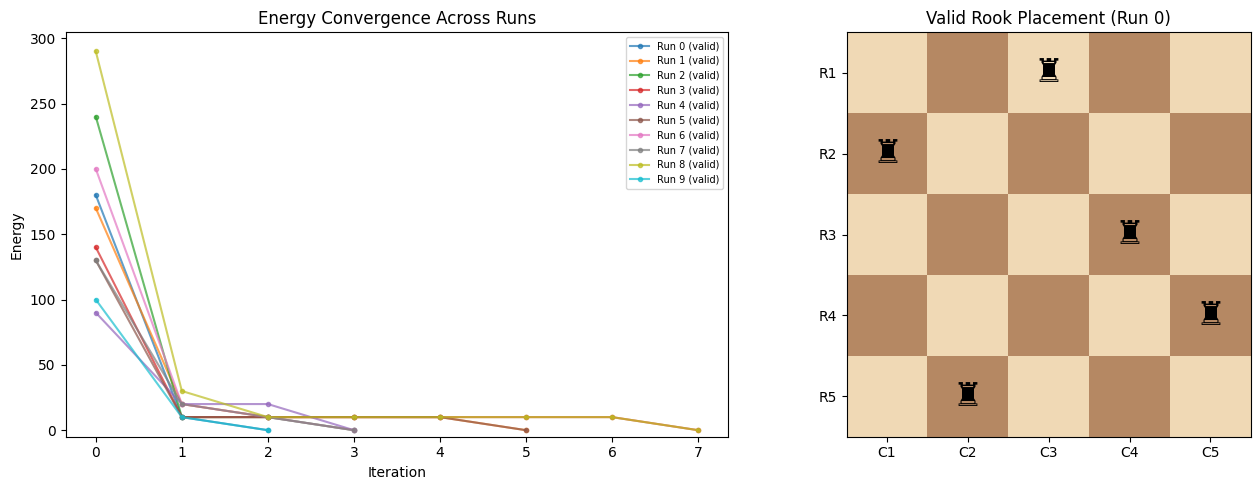

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Energy convergence ---
ax = axes[0]
for run, x_final, energies, valid in results:
    label = f"Run {run} ({'valid' if valid else 'invalid'})"
    ax.plot(energies, alpha=0.7, label=label, marker='o', markersize=3)
ax.set_xlabel('Iteration')
ax.set_ylabel('Energy')
ax.set_title('Energy Convergence Across Runs')
ax.legend(fontsize=7)
ax.set_ylim(bottom=-5)

# --- Right: Chessboard of first valid solution ---
ax = axes[1]
# Find first valid
board = None
board_run = None
for run, x_final, energies, valid in results:
    if valid:
        board = x_final
        board_run = run
        break

if board is not None:
    n = board.shape[0]
    for i in range(n):
        for k in range(n):
            color = '#F0D9B5' if (i + k) % 2 == 0 else '#B58863'
            rect = patches.Rectangle((k, n - 1 - i), 1, 1, facecolor=color)
            ax.add_patch(rect)
            if board[i, k] == 1:
                ax.text(k + 0.5, n - 0.5 - i, '♜', fontsize=24,
                        ha='center', va='center', color='black')

    ax.set_xlim(0, n)
    ax.set_ylim(0, n)
    ax.set_xticks([k + 0.5 for k in range(n)])
    ax.set_xticklabels([f'C{k+1}' for k in range(n)])
    ax.set_yticks([i + 0.5 for i in range(n)])
    ax.set_yticklabels([f'R{n-i}' for i in range(n)])
    ax.set_title(f'Valid Rook Placement (Run {board_run})')
    ax.set_aspect('equal')
else:
    ax.text(0.5, 0.5, 'No valid solution found', ha='center', va='center',
            transform=ax.transAxes, fontsize=14)
    ax.set_title('No Valid Solution')

plt.tight_layout()
plt.show()

## 6. Conclusion

We formulated the 5-Rook Problem as an Ising model following the approach from Lecture 21:

- **Binary variables** $x_{ik} \in \{0,1\}$ encode whether a rook is placed at row $i$, column $k$, forming a $5 \times 5$ matrix of 25 variables
- **Energy function** $E = \frac{\gamma}{2}E_1 + \frac{\gamma}{2}E_2$ uses quadratic penalty terms to enforce that each row and each column contains exactly one rook
- **Gradient-based optimization**: for each variable, we compute $\frac{\partial E}{\partial x_{ik}}$ and set $x_{ik} = 1$ if the derivative is negative (decreases energy) or $x_{ik} = 0$ if positive (would increase energy), iterating until convergence

A valid solution has energy $E = 0$, corresponding to a permutation matrix. The model reliably finds valid rook placements across multiple random initializations, typically converging within a few iterations.